Name:- Samio Hasan,

email:- samiohasan6@gmail.com

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as  sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

Q1


In [ ]:
data = pd.read_csv("/content/titanic_data_updated.csv")
print("Dataset Shape :-",data.shape)
display(data.head(10))
display(data.sample(5))

Dataset Shape :- (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
369,370,yes,first,"Aubart, Mme. Leontine Pauline",female,24.0,0,0,PC 17477,69.3000,B35,C
750,751,yes,second,"Wells, Miss. Joan",female,4.0,1,1,29103,23.0000,NaN,S
109,110,yes,third,"Moran, Miss. Bertha",female,NaN,1,0,371110,24.1500,NaN,Q
138,139,no,third,"Osen, Mr. Olaf Elon",male,16.0,0,0,7534,9.2167,NaN,S
302,303,no,third,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0000,NaN,S


Q2


In [ ]:
data.isnull().sum()
data.duplicated().sum()
data.drop_duplicates(inplace=True)

Q3

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [ ]:
data.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


Q4

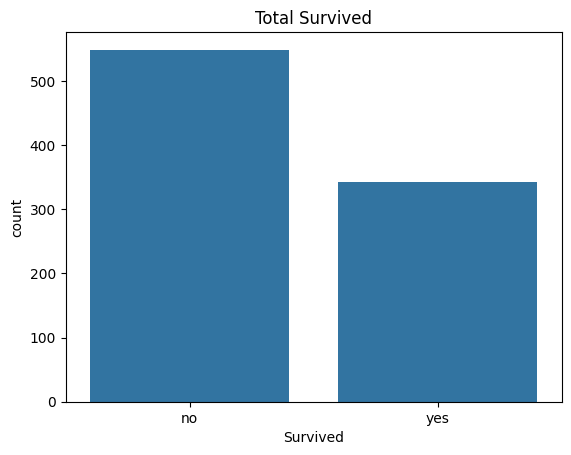

In [ ]:
plt.title("Total Survived")
sns.countplot(data=data,x=data.Survived)

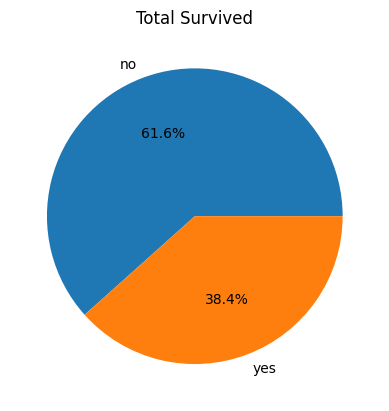

In [ ]:
survive_parcentage = (data.Survived.value_counts()/len(data))*100
survive_label = data.Survived.unique()
plt.title("Total Survived")
plt.pie(survive_parcentage, labels=survive_label, autopct="%1.1f%%")
plt.show()

Q5

<Axes: xlabel='Age', ylabel='Count'>

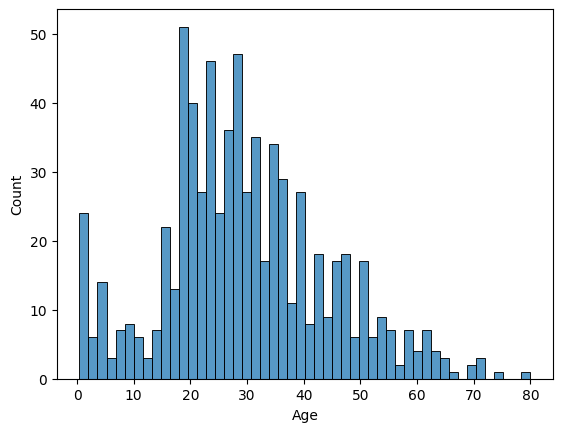

In [ ]:
sns.histplot(data=data,x=data.Age,bins=50)

<Axes: xlabel='Age', ylabel='Density'>

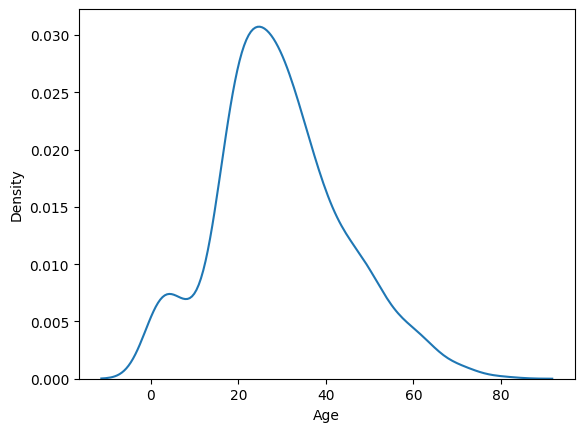

In [ ]:
sns.kdeplot(data=data,x= data.Age)

Q6

<Axes: xlabel='Sex', ylabel='count'>

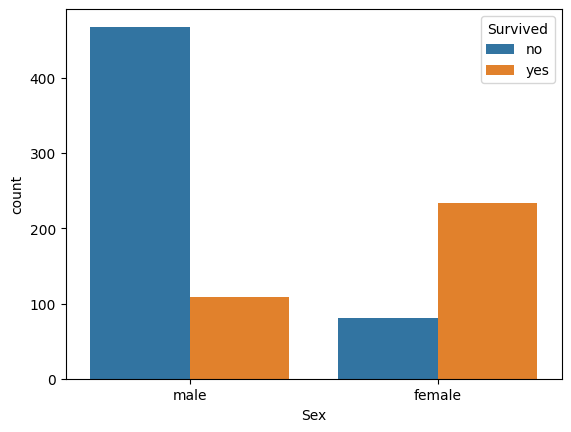

In [ ]:
sns.countplot(data=data,x=data.Sex,hue=data.Survived)

In [ ]:
gender_survived = data.groupby("Sex")["Survived"].value_counts()
gender_survived

Sex     Survived
female  yes         233
        no           81
male    no          468
        yes         109
Name: count, dtype: int64

2 Insights are :-

1.Female Traveller survive more than male.

2.Tought Male Population are greater but they dont suvive much

Q7

<Axes: xlabel='Pclass', ylabel='Fare'>

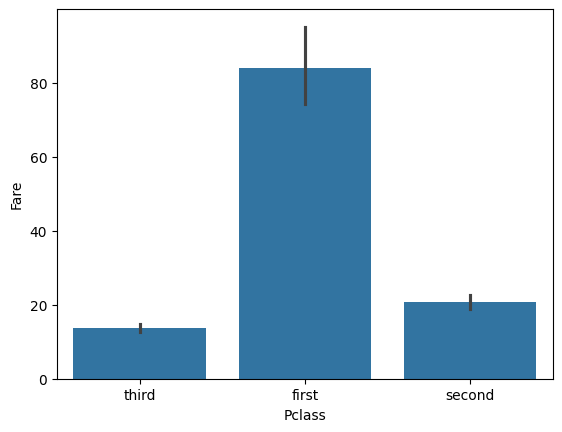

In [ ]:
sns.barplot(data=data,x=data.Pclass,y=data.Fare)

2 Observation:-

1. In First Pclass people give the highest Fare

2. 2nd Highest Fare given people are secound Pclass

Q8

<Axes: xlabel='Age', ylabel='Density'>

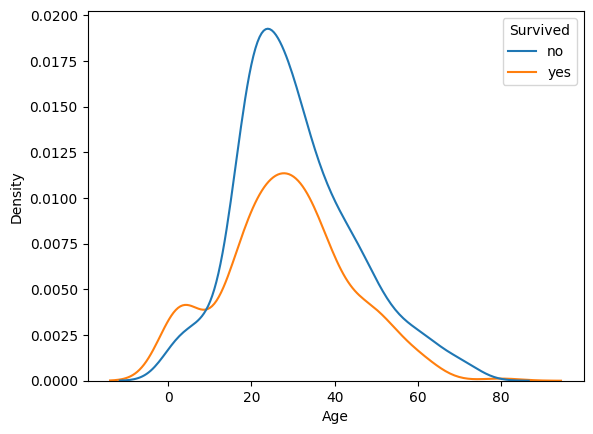

In [ ]:
sns.kdeplot(data=data,x=data.Age,hue=data.Survived)

2 Insights:-

1. The Hights Survival or non survival people lies betwenn 20-30 years.

2. Lowest Surval rates lies between 65+ and also Lowest non Survival rates in 75+ years old

Q9

In [ ]:
data.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S


In [ ]:
x = data.drop("Survived",axis=1) # Feature Cols
y = data.Survived # Target Col


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
x, y, test_size=0.2, random_state=42)

In [ ]:
print(f"X Train Data Shape:- {X_train.shape}")
print(f"X Test Data Shape:- {X_test.shape}")
print(f"Y Train Data Shape:- {y_train.shape}")
print(f"Y Test Data Shape:- {y_test.shape}")

X Train Data Shape:- (712, 8)
X Test Data Shape:- (179, 8)
Y Train Data Shape:- (712,)
Y Test Data Shape:- (179,)


Q10

In [ ]:
age_imputer = SimpleImputer(missing_values=np.nan,strategy="mean")
age_imputer = age_imputer.fit(X_train[["Age"]])
X_train[["Age"]] = age_imputer.transform(X_train[["Age"]])
X_test[["Age"]] = age_imputer.transform(X_test[["Age"]])

In [ ]:
embarked_imp = SimpleImputer(missing_values=np.nan,strategy="most_frequent")
embarked_imp.fit(X_train[["Embarked"]])
X_train[["Embarked"]] = embarked_imp.transform(X_train[["Embarked"]])
X_test[["Embarked"]] = embarked_imp.transform(X_test[["Embarked"]])

In [ ]:
cabin_imp = SimpleImputer(missing_values=np.nan,strategy="constant",fill_value="Missing")
cabin_imp.fit(X_train[["Cabin"]])
X_train[["Cabin"]] = cabin_imp.transform(X_train[["Cabin"]])
X_test[["Cabin"]] = cabin_imp.transform(X_test[["Cabin"]])

In [ ]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


In [ ]:
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
